<a href="https://colab.research.google.com/github/Qarym/Covid-19-Data-Analysis/blob/main/Untitled11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

#

In [1]:
from google.colab import files
uploaded= files.upload()


Saving archive.zip to archive.zip


After Uploading the dataset, we look at the characteristics of the data in the dataset.



In [3]:
import pandas as pd

In [4]:
df= pd.read_csv('archive.zip')

In [5]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df.shape

(545, 13)

In [7]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
def data_clean(df):
    df.fillna(0, inplace=True)
    print(df.isnull().sum())

In [9]:
data_clean(df)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Univariate Analysis

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display data types
print("Data Types:")
display(df.info())

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None


Descriptive Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Distribution of Price

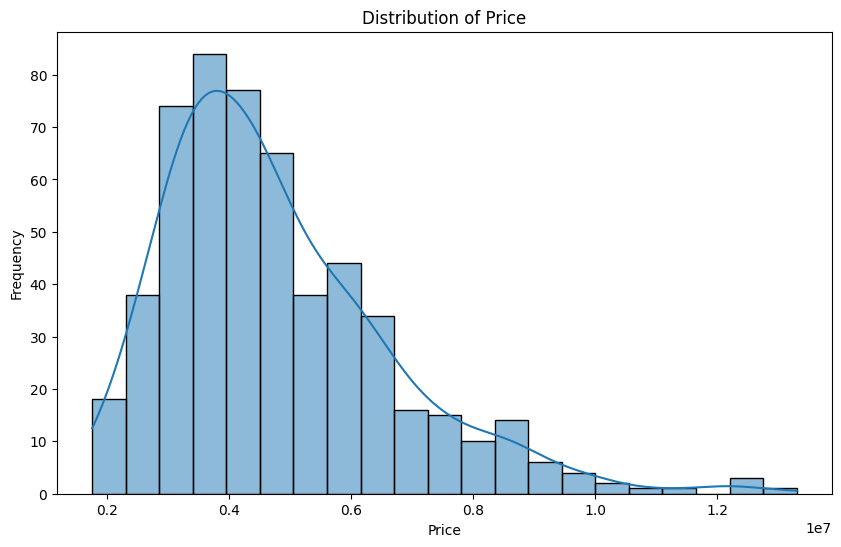

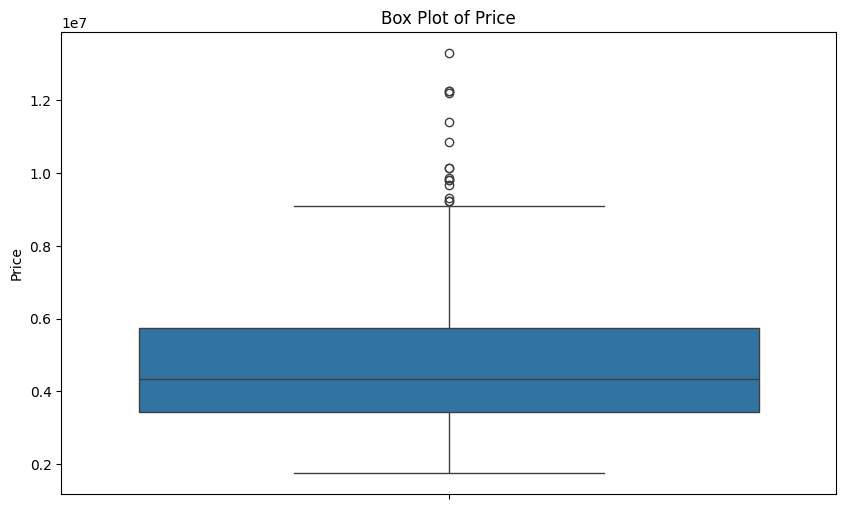

In [11]:
# Histogram of Price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Box plot of Price
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

## Bivariate Analysis

### Price vs. Area

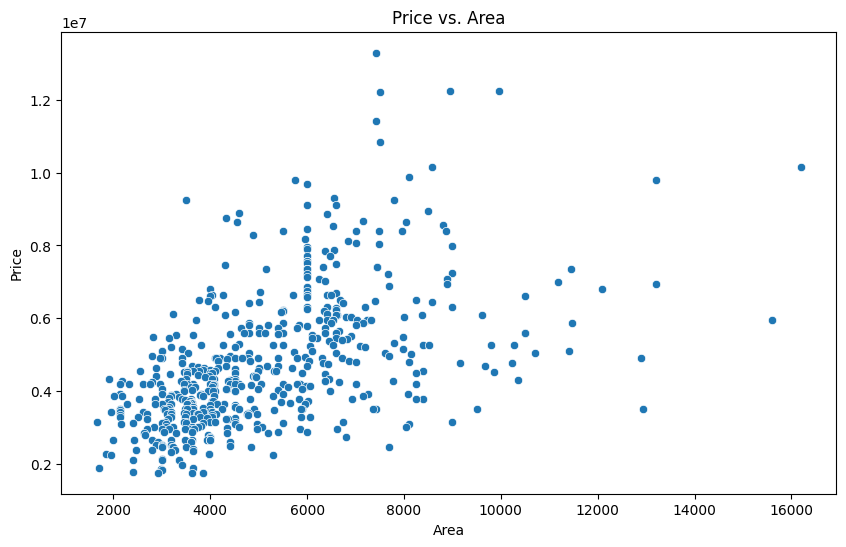

In [12]:
# Scatter plot of Price vs. Area
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['area'], y=df['price'])
plt.title('Price vs. Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

## Feature Engineering: Identifying Important Features

### Correlation Matrix for Numerical Features

Correlation with Price:


,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


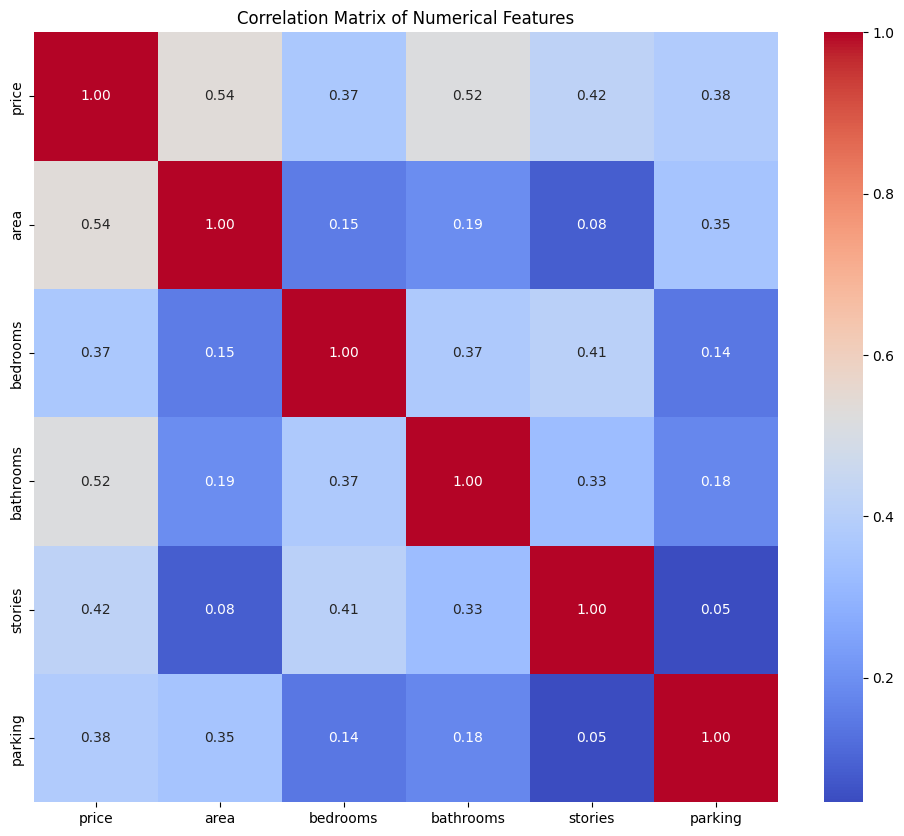

In [13]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation of all numerical features with 'price'
print("Correlation with Price:")
display(correlation_matrix['price'].sort_values(ascending=False))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Analysis of Categorical Features vs. Price

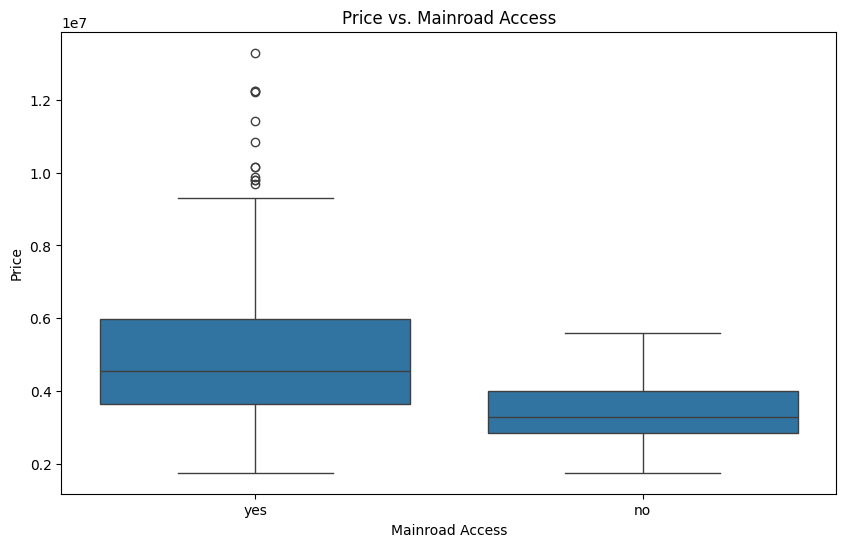

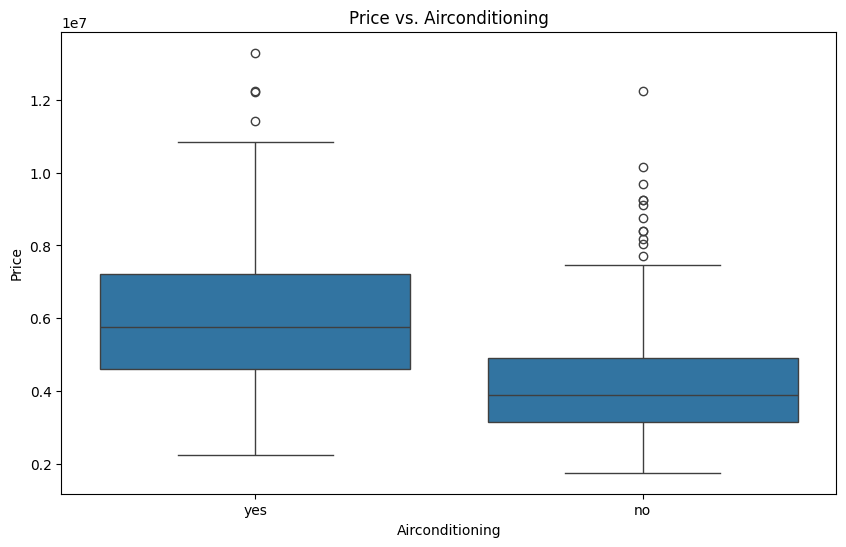

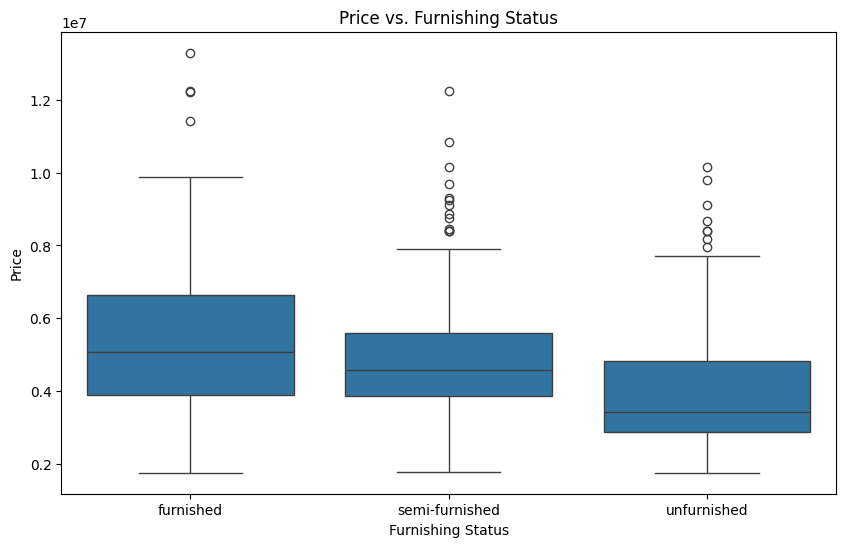

In [14]:
# Box plot of Price vs. Mainroad
plt.figure(figsize=(10, 6))
sns.boxplot(x='mainroad', y='price', data=df)
plt.title('Price vs. Mainroad Access')
plt.xlabel('Mainroad Access')
plt.ylabel('Price')
plt.show()

# Box plot of Price vs. Airconditioning
plt.figure(figsize=(10, 6))
sns.boxplot(x='airconditioning', y='price', data=df)
plt.title('Price vs. Airconditioning')
plt.xlabel('Airconditioning')
plt.ylabel('Price')
plt.show()

# Box plot of Price vs. Furnishing Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Price vs. Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.show()

**The exploratory data analysis identified several key factors that strongly influence house prices.**

Among the numerical variables, area (correlation = 0.54) and bathrooms (correlation = 0.52) exhibited the strongest positive relationships with price, indicating that larger homes with more bathrooms generally command higher market values. Additionally, stories, parking, and bedrooms demonstrated moderate positive correlations, suggesting they also contribute meaningfully to property value.

For the categorical variables, box plot analysis revealed that mainroad access, airconditioning, and furnishingstatus have a significant impact on house prices. Properties located along a main road, equipped with air conditioning, and sold as furnished consistently achieved higher prices than semi-furnished and unfurnished homes.

Overall, the analysis highlights area, bathrooms, mainroad access, airconditioning, and furnishingstatus as the most influential features for predicting house prices. These variables provide a strong foundation for developing an accurate and reliable predictive model.

The next logical step is to prepare the data for modeling by encoding categorical variables, scaling numerical features where appropriate, and splitting the dataset into training and testing sets before building and evaluating a house price prediction model.